In [1]:
# importing the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# reading the data 
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# independent and dependent feature
X = df.drop('math_score',axis=1)
y = df['math_score']

In [5]:
# Column Transformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns


num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()


preprocess = ColumnTransformer(
    [
        ("OneHotEncoder",cat_transformer,cat_features),
        ("StandardScaler",num_transformer,num_features)
    ]
)

In [6]:
X = preprocess.fit_transform(X)

In [8]:
X.shape

(1000, 19)

In [9]:
# train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
# Function for evaluation metrics
def evaluate_model(true,predicted):
    mse = mean_squared_error(true,predicted)
    mae = mean_absolute_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2 = r2_score(true,predicted)

    return mse,mae,rmse,r2

In [11]:
# Model Training
models = {
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(),
    "Lasso":Lasso(),
    "KNN":KNeighborsRegressor(),
    "SVR":SVR(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "Adaboost":AdaBoostRegressor(),
    "XGBoost":XGBRegressor(),
    "Catboost":CatBoostRegressor()
}

model_lst = []
r2_lst = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    model_lst.append(list(models.keys())[i])

    y_pred = model.predict(X_test)

    mse,mae,rmse,r2 = evaluate_model(y_test,y_pred)

    print(list(models.keys())[i])
    print("MSE:",mse)
    print("MAE:",mae)
    print("RMSE:",rmse)
    print("R2_score:",r2)
    r2_lst.append(r2)

    print("-"*30)

Linear Regression
MSE: 29.095169866715484
MAE: 4.21476314247485
RMSE: 5.393993869732842
R2_score: 0.8804332983749565
------------------------------
Ridge Regression
MSE: 29.056272192348285
MAE: 4.21110068801426
RMSE: 5.390387016935638
R2_score: 0.8805931485028738
------------------------------
Lasso
MSE: 42.50641683841163
MAE: 5.157881810347763
RMSE: 6.519694535667421
R2_score: 0.8253197323627852
------------------------------
KNN
MSE: 52.6066
MAE: 5.621
RMSE: 7.253040741647602
R2_score: 0.7838129945787431
------------------------------
SVR
MSE: 66.0420049374565
MAE: 5.401539244496997
RMSE: 8.126623218622633
R2_score: 0.7286001513223704
------------------------------
Decision Tree
MSE: 67.485
MAE: 6.495
RMSE: 8.21492544092763
R2_score: 0.7226701581008177
------------------------------
Random Forest
MSE: 35.455542468041386
MAE: 4.6452970238095235
RMSE: 5.954455681927726
R2_score: 0.8542953250779927
------------------------------
Adaboost
MSE: 36.62291321738253
MAE: 4.752953107666689
RMS

In [12]:
pd.DataFrame(list(zip(model_lst, r2_lst)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
6,Random Forest,0.854295
9,Catboost,0.851632
7,Adaboost,0.849498
8,XGBoost,0.827797
2,Lasso,0.825320
3,KNN,0.783813
4,SVR,0.728600
5,Decision Tree,0.722670


In [14]:
# Linear Model 
lr = LinearRegression(fit_intercept=True)
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test,y_pred)
print(r2*100)

88.04332983749565


Text(0, 0.5, 'Predicted')

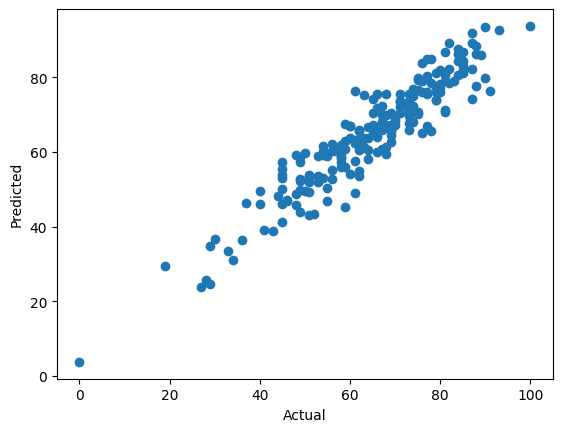

In [16]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')